In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import math
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
def runProblem14():
  """
  Diniz Chapter 7, Problem 14.

    x(k) = sin(pi*k/4)
    lambda = 0.99

  Assumptions not specified by the problem:
    predictor order = 2
    epsilon = 0.01

  The current NormalizedLatticeRLS.step() also executes the joint-process
  branch. For prediction only, set d(k)=0 and ignore delta_D/e/eta_D.
  """

  n_iter = 10

  alg = adspfilter.NormalizedLatticeRLS(
    filter_order=1,
    lam=0.99,
    epsilon=0.01,
  )

  print(
    " k      x(k)       ef_bar(k,2)    delta_bar(0)    delta_bar(1)"
    "      eta_f(1)      eta_f(2)      eta_b(1)      eta_b(2)"
  )

  print("-" * 116)

  for k in range(n_iter):
    xk = np.sin(np.pi * k / 4.0)
    result = alg.step(xk=float(xk), dk=0.0,)
    ef = result["ef_bar"]
    delta = result["delta_bar"]
    eta_f = result["eta_f"]
    eta_b = result["eta_b"]

    print(
      f"{k:2d}  "
      f"{xk:10.6f}  "
      f"{ef[-1]:14.6f}  "
      f"{delta[0]:14.6f}  "
      f"{delta[1]:14.6f}  "
      f"{eta_f[0]:12.6f}  "
      f"{eta_f[1]:12.6f}  "
      f"{eta_b[0]:12.6f}  "
      f"{eta_b[1]:12.6f}"
    )
runProblem14()

 k      x(k)       ef_bar(k,2)    delta_bar(0)    delta_bar(1)      eta_f(1)      eta_f(2)      eta_b(1)      eta_b(2)
--------------------------------------------------------------------------------------------------------------------
 0    0.000000        0.000000        0.000000        0.000000      1.000000      1.000000      1.000000      1.000000
 1    0.707107        0.990341        0.000000        0.000000      1.000000      1.000000      7.212157      7.212157
 2    1.000000        0.191557        0.807345        0.000000     12.222349      1.000000      2.926153      1.018868
 3    0.707107       -0.127428        0.813249       -0.466302      2.967205      4.810786      1.986031      1.288356
 4    0.000000       -0.038427        0.703684       -0.688696      1.626574      2.348490      1.407434      1.684007
 5   -0.707107       -0.026390        0.627789       -0.806925      1.284713      2.389048      1.440026      2.078992
 6   -1.000000       -0.016314        0.715370    

## Common helpers

For system identification,

$[d(k)=\mathbf w_o^T(k)\mathbf x(k)+n(k)]$

The time-varying unknown system in Problems 15–16 follows the first-order Markov model

$[\mathbf w_o(k+1)=\lambda_w\mathbf w_o(k)+\mathbf n_w(k),]$

where every element of $(\mathbf n_w(k))$ is zero-mean white noise with variance $(\sigma_w^2)$.

For an a-posteriori LRLS implementation,
$[\epsilon(k,N+1)=\gamma(k,N+1)e(k,N+1),]$

so the physical a-priori output error is

$[e(k,N+1)=\frac{\epsilon(k,N+1)}{\gamma(k,N+1)}.]$


In [3]:
def rlsTrackingTheory(
    lam: float,
    lambda_w: float = 0.999,
    sigma_w2: float = 0.033,
    sigma_x2: float = 1.0,
    sigma_n2: float = 0.01,
    filter_order: int = 7,
) -> dict:
  """Diniz Ch. 5 tracking formulas used as a cross-check for Problems 15-16."""
  n_coef = filter_order + 1

  denominator = lambda_w * (1.0 + lam**2) - lam * (1.0 + lambda_w**2)
  ratio = (1.0 - lam) / (1.0 + lam) - (1.0 - lambda_w) / (1.0 + lambda_w)

  xi_lag = n_coef * sigma_w2 * sigma_x2 * ratio / denominator
  xi_memory = n_coef * (1.0 - lam) / (1.0 + lam) * sigma_n2

  return {
    "xi_lag": xi_lag,
    "xi_memory": xi_memory,
    "xi_excess_total": xi_lag + xi_memory,
  }
  
def makeRegressor(x_pad: np.ndarray, k: int, n_coef: int) -> np.ndarray:
  return x_pad[k:k + n_coef][::-1]

lambda=0.97: simulated excess MSE=5.100839, Ch.5 theory≈4.330479
lambda=0.99: simulated excess MSE=12.583985, Ch.5 theory≈12.077716


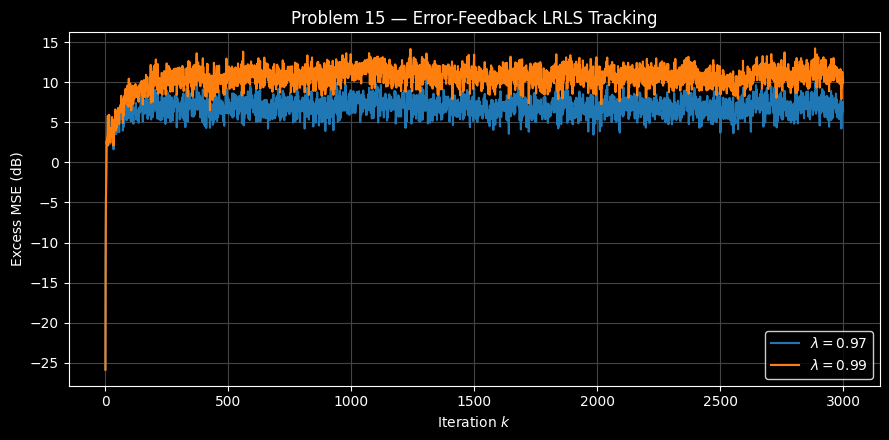

In [4]:
W0_P15 = np.array([
  0.03490, -0.01100, -0.06864, 0.22391,
  0.55686, 0.35798, -0.02390, -0.07594,
], dtype=np.float64)


def runProblem15(
    lam: float,
    n_runs: int = 50,
    n_samples: int = 3000,
    steady_start: int = 500,
    seed: int = 2026,
) -> dict:
  lambda_w = 0.999
  sigma_w2 = 0.033
  sigma_x2 = 1.0
  sigma_n2 = 0.01

  mse = np.zeros(n_samples, dtype=np.float64)
  master_rng = np.random.default_rng(seed)

  for _ in range(n_runs):
    rng = np.random.default_rng(master_rng.integers(0, 2**32 - 1))

    x = rng.normal(0.0, math.sqrt(sigma_x2), n_samples)
    n = rng.normal(0.0, math.sqrt(sigma_n2), n_samples)
    x_pad = np.concatenate([np.zeros(7), x])

    w_true = W0_P15.copy()

    alg = adspfilter.ErrorFeedbackLatticeRLS(
      filter_order=7,
      lam=lam,
      epsilon=0.1,
    )

    for k in range(n_samples):
      reg = makeRegressor(x_pad, k, 8)
      d_k = float(np.dot(w_true, reg) + n[k])

      result = alg.step(float(x[k]), d_k)

      gamma_out = max(float(result["gamma"][-1]), alg.eps)
      e_prior = float(result["e"]) / gamma_out
      mse[k] += e_prior * e_prior

      w_true = lambda_w * w_true + rng.normal(0.0, math.sqrt(sigma_w2), 8)

  mse /= n_runs
  excess_curve = mse - sigma_n2
  excess_ss = float(np.mean(excess_curve[steady_start:]))

  return {
    "lambda": lam,
    "mse": mse,
    "excess_curve": excess_curve,
    "excess_ss": excess_ss,
  }


p15_097 = runProblem15(0.97)
p15_099 = runProblem15(0.99)

for result in (p15_097, p15_099):
  theory = rlsTrackingTheory(result["lambda"])
  print(
    f"lambda={result['lambda']:.2f}: "
    f"simulated excess MSE={result['excess_ss']:.6f}, "
    f"Ch.5 theory≈{theory['xi_excess_total']:.6f}"
  )
plt.figure(figsize=(9, 4.5))
plt.plot(10.0 * np.log10(np.maximum(p15_097["excess_curve"], 1e-12)), label=r"$\lambda=0.97$")
plt.plot(10.0 * np.log10(np.maximum(p15_099["excess_curve"], 1e-12)), label=r"$\lambda=0.99$")
plt.xlabel("Iteration $k$")
plt.ylabel("Excess MSE (dB)")
plt.title("Problem 15 — Error-Feedback LRLS Tracking")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

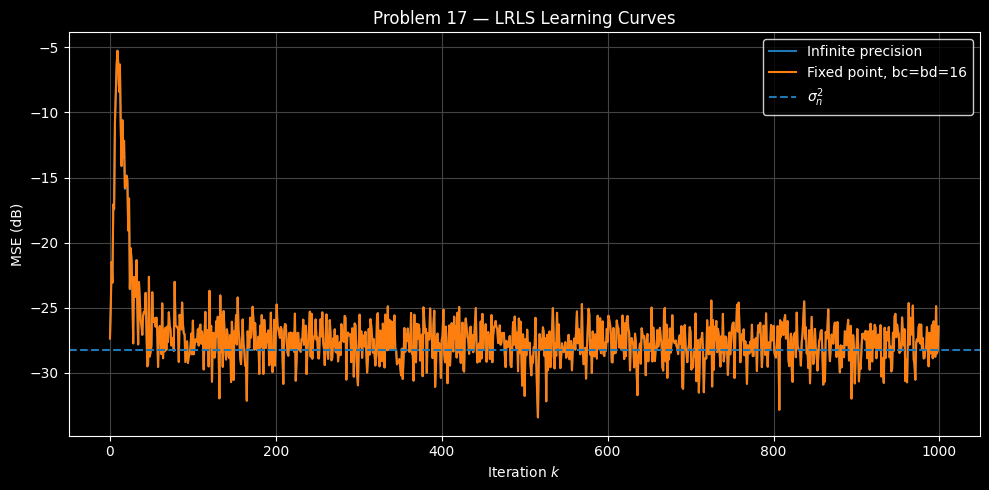

In [8]:
W0_P17 = np.array([
    0.0219360,  0.0015786, -0.0602449, -0.0118907,
    0.1375379,  0.0574545, -0.3216703, -0.5287203,
   -0.2957797,  0.0002043,  0.2906700, -0.0353349,
   -0.0068210,  0.0026067,  0.0010333, -0.0143593,
], dtype=np.float64)
def runProblem17(
    n_runs: int = 200,
    n_samples: int = 1500,
    epsilon: float = 0.1,
    seed: int = 2026,
):
    filter_order = 15
    n_coef = filter_order + 1

    lam = 0.98

    sigma_x2 = 0.7
    sigma_n2 = 0.0015

    bc = 16
    bd = 16

    mse_float = np.zeros(n_samples, dtype=np.float64)
    mse_fixed = np.zeros(n_samples, dtype=np.float64)

    dkappa_f2 = np.zeros(n_samples, dtype=np.float64)
    dkappa_b2 = np.zeros(n_samples, dtype=np.float64)

    master_rng = np.random.default_rng(seed)

    for _ in range(n_runs):
        rng = np.random.default_rng(master_rng.integers(0, 2**32 - 1))

        x = rng.normal(0.0, np.sqrt(sigma_x2), n_samples)
        noise = rng.normal(0.0, np.sqrt(sigma_n2), n_samples)

        x_pad = np.concatenate([np.zeros(n_coef - 1), x])

        lrls_float = adspfilter.LatticeRLS(
            filter_order=filter_order,
            lam=lam,
            epsilon=epsilon,
        )

        lrls_fixed = adspfilter.QuantizedLatticeRLS(
            filter_order=filter_order,
            lam=lam,
            epsilon=epsilon,
            bc=bc,
            bd=bd,
        )

        for k in range(n_samples):
            reg = x_pad[k : k + n_coef][::-1]
            d_k = np.dot(W0_P17, reg) + noise[k]

            result_float = lrls_float.step(x[k], d_k)
            result_fixed = lrls_fixed.step(x[k], d_k)

            # -----------------------------------------------------------------------
            # Convert the Algorithm-7.1 a-posteriori error to physical a-priori error.
            #
            #   epsilon(k,N+1) = gamma(k,N+1) e(k,N+1)
            # -----------------------------------------------------------------------
            gamma_float = max(float(result_float["gamma"][-1]), lrls_float.eps)
            gamma_fixed = max(float(result_fixed["gamma"][-1]), lrls_fixed.coef_lsb)

            e_float = float(result_float["e"]) / gamma_float
            e_fixed = float(result_fixed["e"]) / gamma_fixed

            mse_float[k] += e_float * e_float
            mse_fixed[k] += e_fixed * e_fixed

            # -----------------------------------------------------------------------
            # Quantization error in the first lattice reflection coefficients.
            # -----------------------------------------------------------------------
            delta_kappa_f = float(result_fixed["kappa_f"][0]) - float(result_float["kappa_f"][0])
            delta_kappa_b = float(result_fixed["kappa_b"][0]) - float(result_float["kappa_b"][0])

            dkappa_f2[k] += delta_kappa_f * delta_kappa_f
            dkappa_b2[k] += delta_kappa_b * delta_kappa_b

    mse_float /= n_runs
    mse_fixed /= n_runs

    dkappa_f2 /= n_runs
    dkappa_b2 /= n_runs

    return {
        "mse_float": mse_float,
        "mse_fixed": mse_fixed,
        "dkappa_f2": dkappa_f2,
        "dkappa_b2": dkappa_b2,
        "n_runs": n_runs,
        "n_samples": n_samples,
        "bc": bc,
        "bd": bd,
    }


# Execute simulation
result = runProblem17(n_runs=20, n_samples=1000)
k = np.arange(result["n_samples"])

# Plot learning curves
plt.figure(figsize=(10, 5))
plt.plot(k, 10.0 * np.log10(np.maximum(result["mse_float"], 1e-16)), label="Infinite precision")
plt.plot(k, 10.0 * np.log10(np.maximum(result["mse_fixed"], 1e-16)), label="Fixed point, bc=bd=16")
plt.axhline(10.0 * np.log10(0.0015), linestyle="--", label=r"$\sigma_n^2$")
plt.xlabel("Iteration $k$")
plt.ylabel("MSE (dB)")
plt.title("Problem 17 — LRLS Learning Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()